# Cogniland — Map Sampler

Sample and visualise procedurally generated maps from each env config.

In [13]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from cogniland.env.islands import generate_island, colorize
from cogniland.env.types import EnvConfig
from cogniland.env.constants import TERRAIN_LEVELS, palette

In [14]:
# ── Config definitions (mirror the YAML files) ────────────────────────────────

CONFIGS = {
    "default": EnvConfig(
        size=250, scale=0.33, octaves=6, persistence=0.5, lacunarity=2.0,
        filtering="square", sink_mode=1,
    ),
    "circle filter": EnvConfig(
        size=250, scale=0.33, octaves=6, persistence=0.5, lacunarity=2.0,
        filtering="circle", sink_mode=1,
    ),
    "diamond filter": EnvConfig(
        size=250, scale=0.33, octaves=6, persistence=0.5, lacunarity=2.0,
        filtering="diamond", sink_mode=1,
    ),
    "more octaves": EnvConfig(
        size=250, scale=0.33, octaves=16, persistence=0.5, lacunarity=2.0,
        filtering="square", sink_mode=1,
    ),
    "high persistence": EnvConfig(
        size=250, scale=0.33, octaves=6, persistence=1, lacunarity=2.0,
        filtering="square", sink_mode=1,
    ),
}

In [15]:
def sample_maps(config: EnvConfig, n: int = 4, seed: int = 42) -> list[torch.Tensor]:
    """Generate n maps from the given EnvConfig."""
    maps = []
    for i in range(n):
        s = seed + i
        torch.manual_seed(s)
        random.seed(s)
        np.random.seed(s)
        maps.append(generate_island(config))
    return maps


def show_maps(config_name: str, config: EnvConfig, n: int = 4, seed: int = 42):
    """Sample n maps and display them in a row."""
    maps = sample_maps(config, n=n, seed=seed)

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, world in zip(axes, maps):
        rgb = colorize(world, config).numpy().astype("uint8")
        ax.imshow(rgb)
        ax.axis("off")

    fig.suptitle(config_name, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

## Sample maps — one row per config

Change `N_MAPS` or `SEED` to explore different seeds / pool sizes.

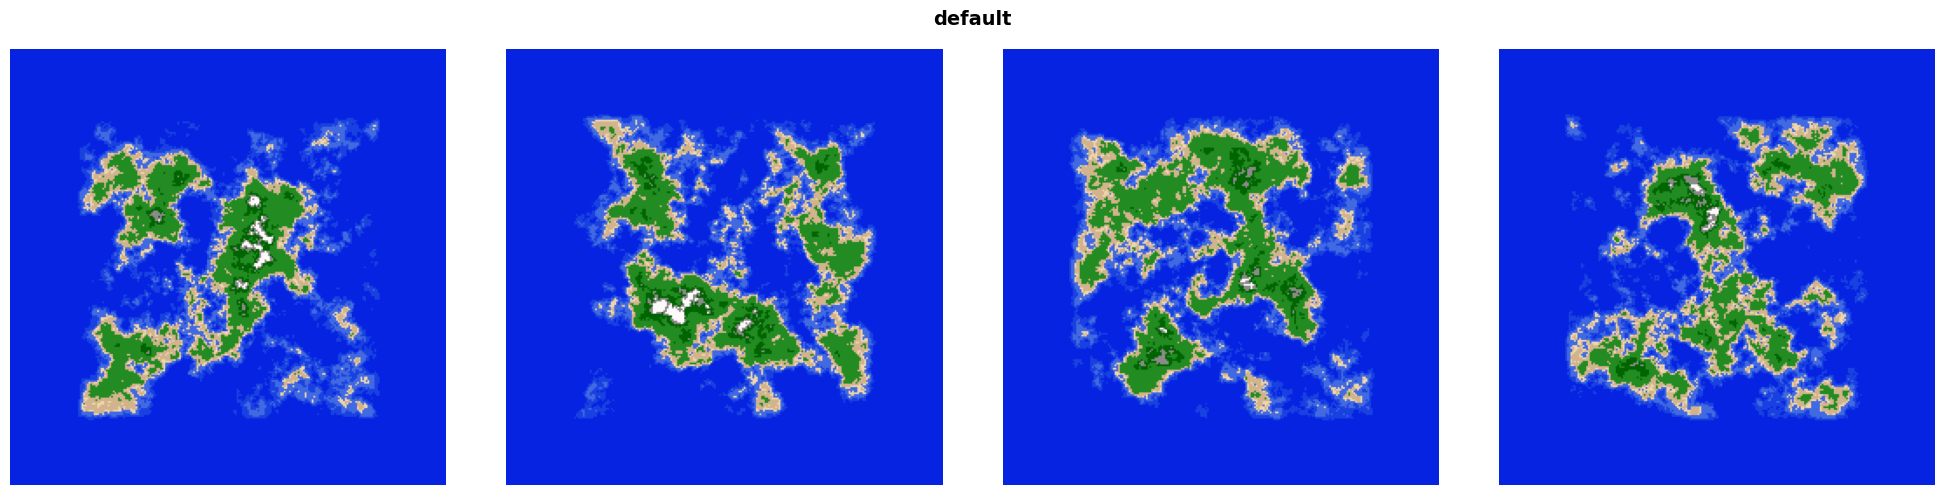

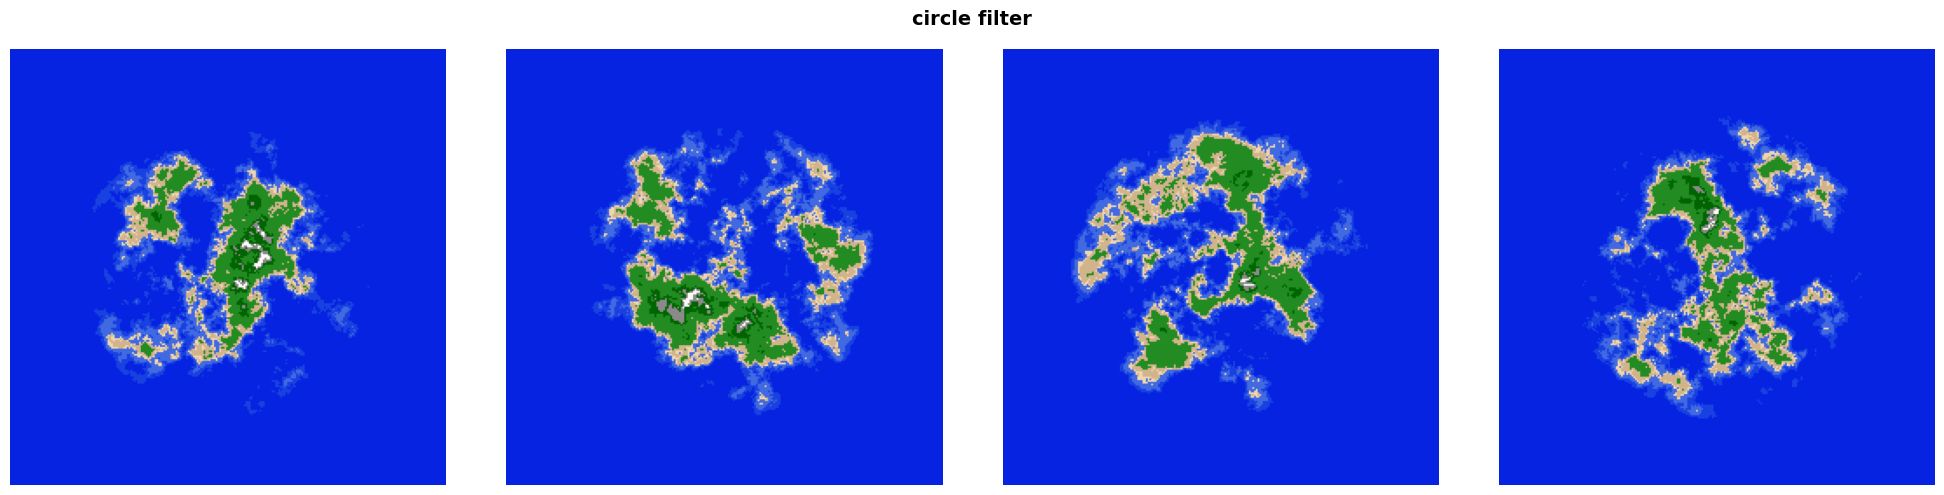

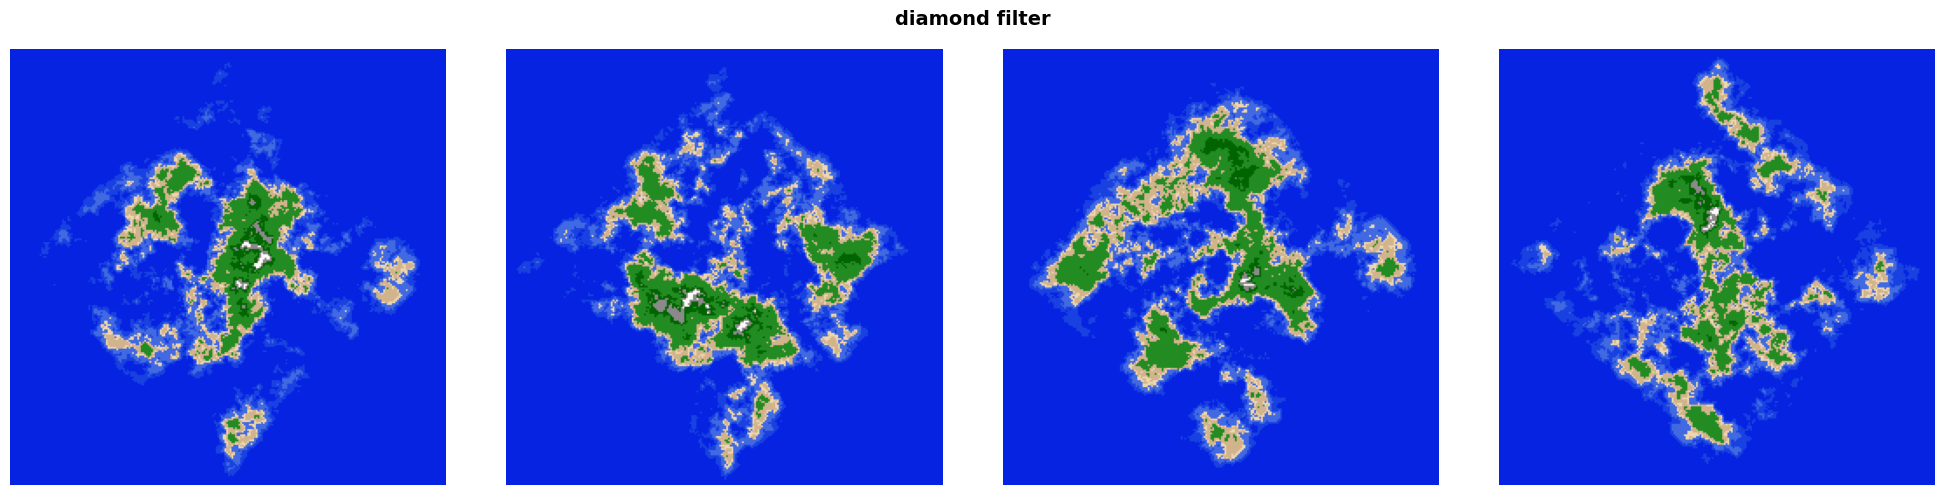

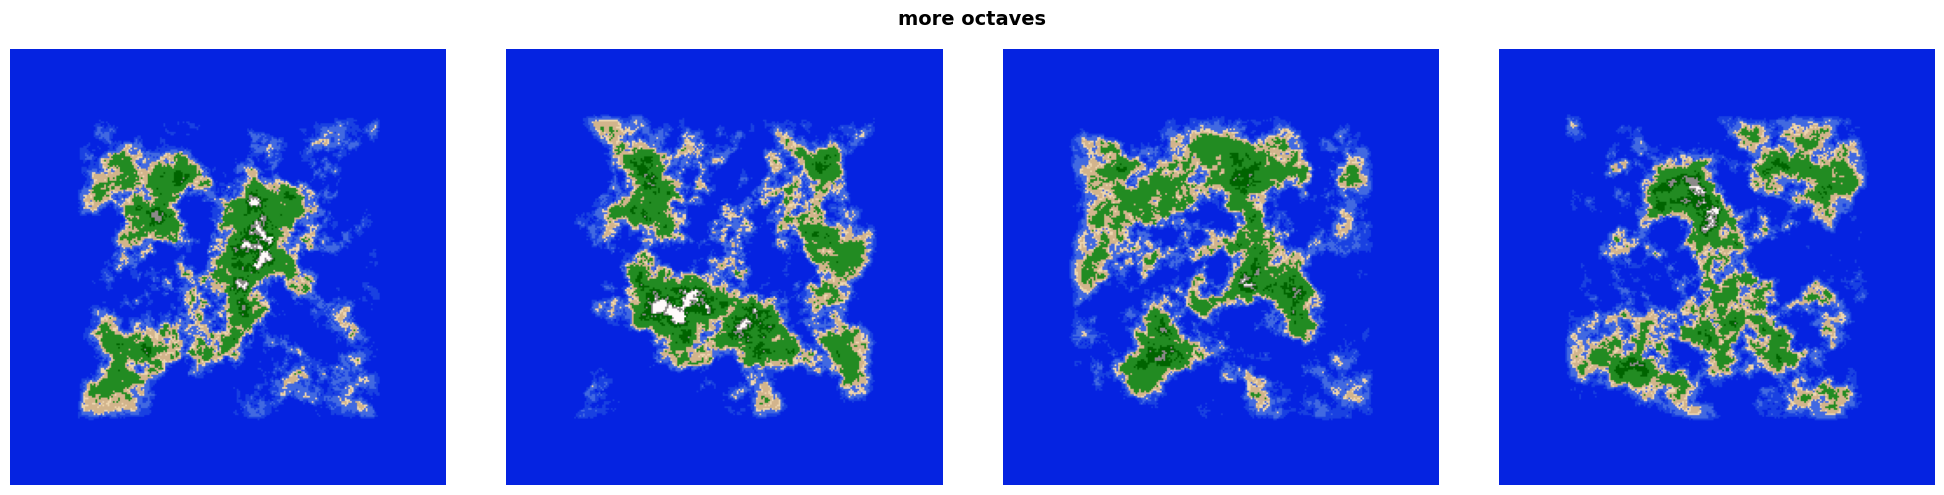

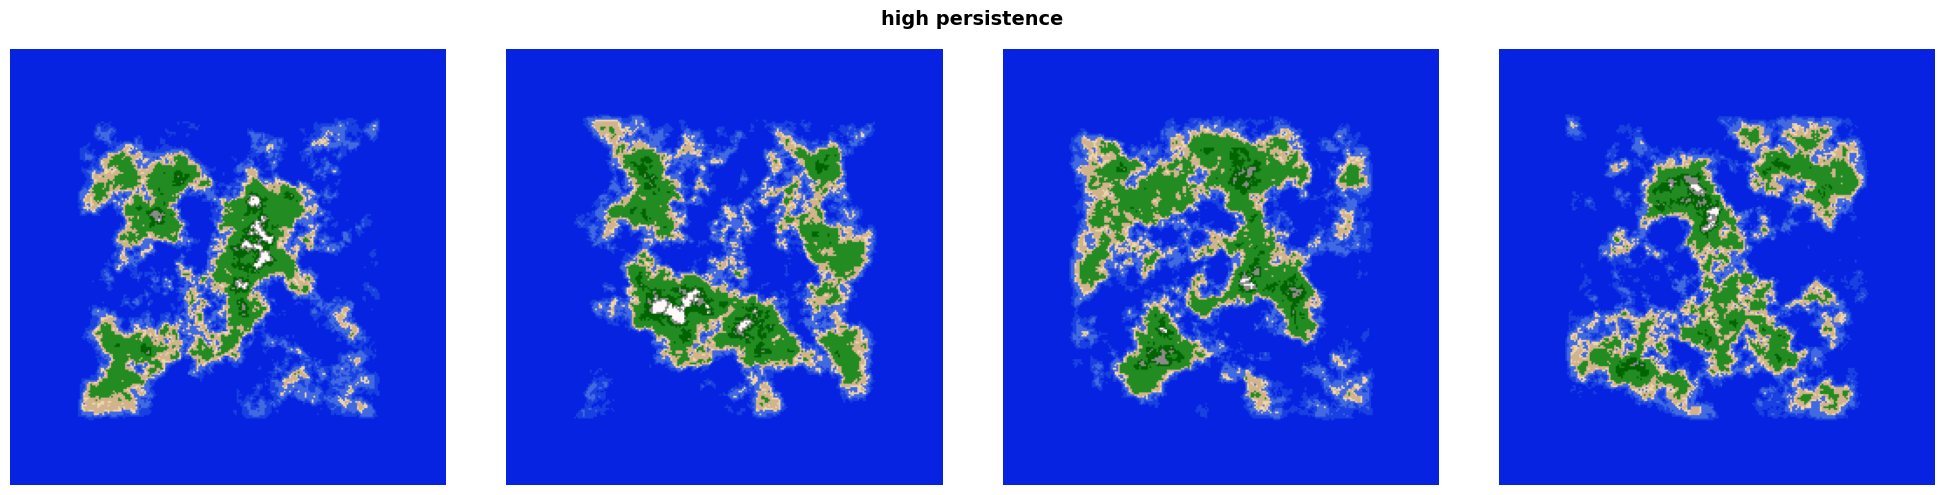

In [16]:
N_MAPS = 4
SEED = 42

for name, cfg in CONFIGS.items():
    show_maps(name, cfg, n=N_MAPS, seed=SEED)

## Interactive single-map inspector

Pick a config and seed below, then run the cell to get a large view plus terrain stats.

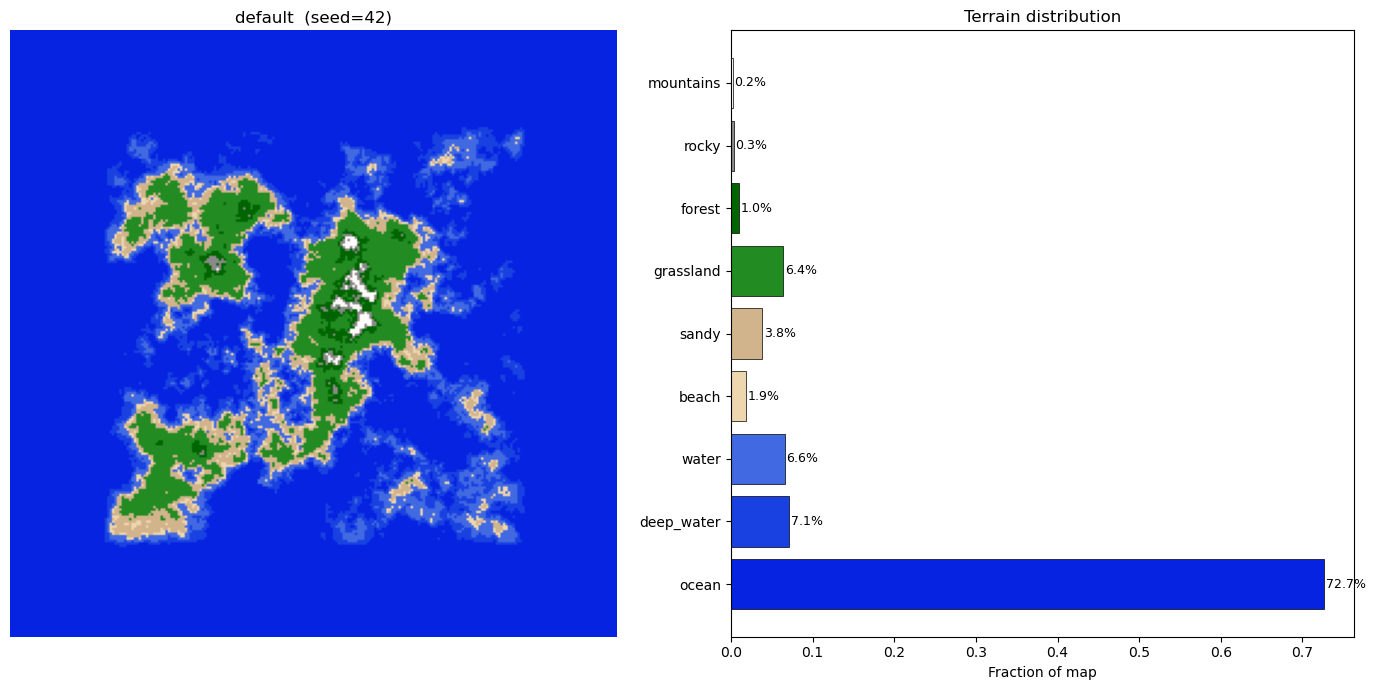

In [17]:
CONFIG_NAME = "default"   # key from CONFIGS dict above
SEED_SINGLE = 42

cfg = CONFIGS[CONFIG_NAME]
torch.manual_seed(SEED_SINGLE)
random.seed(SEED_SINGLE)
np.random.seed(SEED_SINGLE)
world = generate_island(cfg)
rgb = colorize(world, cfg).numpy().astype("uint8")

# Compute terrain distribution
from cogniland.env.constants import TERRAIN_THRESHOLDS
from cogniland.env.core import compute_terrain_levels

H, W = world.shape
flat = world.reshape(-1)  # [H*W]

# Assign terrain index to every cell using the threshold table
thresholds = TERRAIN_THRESHOLDS  # [9]
terrain_map = torch.zeros(H * W, dtype=torch.long)
# threshold[i] is the upper bound for terrain i, with a 0.02/0.1/0.2 base offset
base = 0.02 if cfg.sink_mode == 1 else (0.1 if cfg.sink_mode == 2 else 0.2)
for t_idx in range(8, -1, -1):
    terrain_map[flat < base + thresholds[t_idx]] = t_idx

counts = torch.bincount(terrain_map, minlength=9).float()
fracs = counts / counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(rgb)
axes[0].set_title(f"{CONFIG_NAME}  (seed={SEED_SINGLE})", fontsize=12)
axes[0].axis("off")

terrain_names = [TERRAIN_LEVELS[i]["name"] for i in range(9)]
colors = [[c / 255 for c in palette[TERRAIN_LEVELS[i]["color"]]] for i in range(9)]
bars = axes[1].barh(terrain_names, fracs.numpy(), color=colors, edgecolor="black", linewidth=0.5)
axes[1].set_xlabel("Fraction of map")
axes[1].set_title("Terrain distribution")
for bar, frac in zip(bars, fracs):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                 f"{frac:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## Seed sweep — how much does the map vary across seeds?

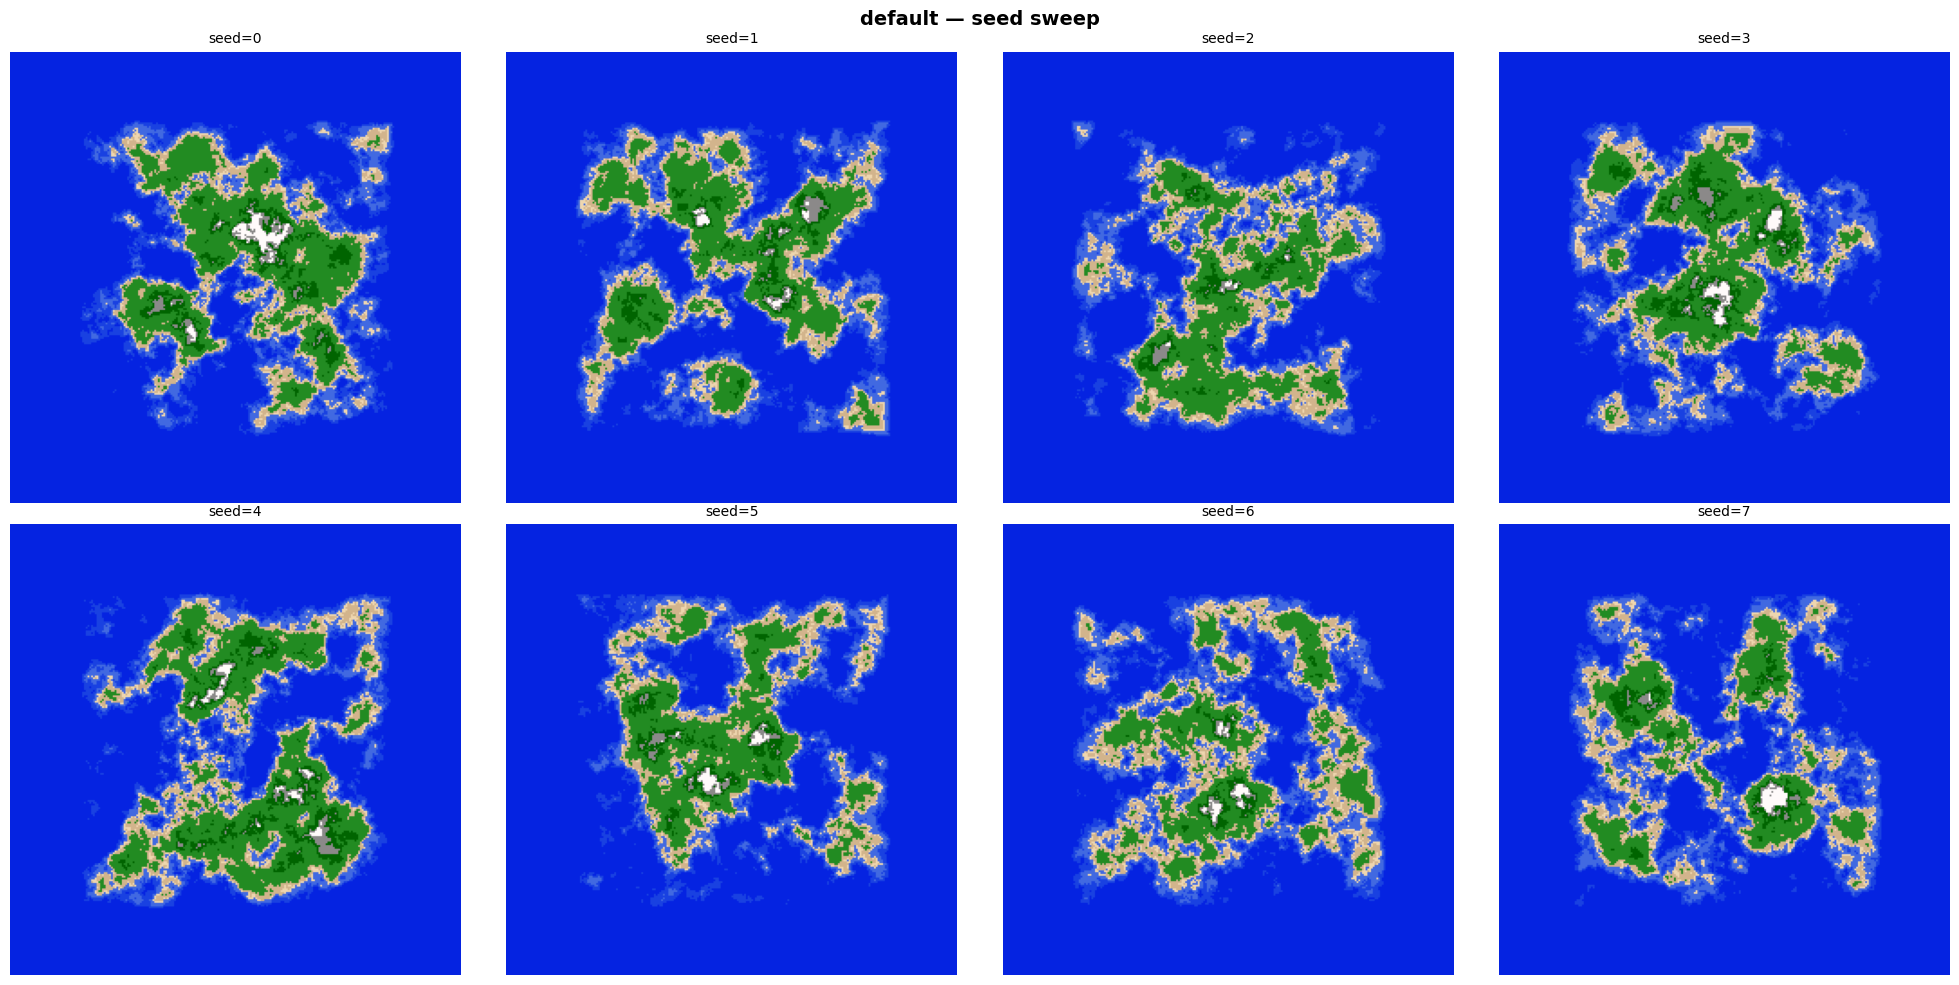

In [18]:
SWEEP_CONFIG = "default"
N_SEEDS = 8
SEEDS = list(range(N_SEEDS))

cfg = CONFIGS[SWEEP_CONFIG]
maps = sample_maps(cfg, n=N_SEEDS, seed=0)

cols = 4
rows = (N_SEEDS + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = axes.flat

for ax, (world, s) in zip(axes, zip(maps, SEEDS)):
    rgb = colorize(world, cfg).numpy().astype("uint8")
    ax.imshow(rgb)
    ax.set_title(f"seed={s}", fontsize=10)
    ax.axis("off")

for ax in list(axes)[N_SEEDS:]:
    ax.axis("off")

fig.suptitle(f"{SWEEP_CONFIG} — seed sweep", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()